# Imports

In [1]:
import os
import sys
import json
import yt_dlp
import whisper
import librosa
import numpy as np

# Voice Transcription & Music Selection

In [2]:
import os
import json
import whisper
import librosa
import numpy as np

# --- STEP 1: THE SENSOR (Detects Happiness, Sadness, and Speed) ---
def analyze_enhanced_sentiment(y, sr):
    """Calculates if the music is happy/sad (Valence) and fast/intense (Arousal)"""
    # 1. Harmony (Major = Happy, Minor = Sad)
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    mean_chroma = np.mean(chroma, axis=1)
    tonic_idx = np.argmax(mean_chroma)
    major_3rd, minor_3rd = (tonic_idx + 4) % 12, (tonic_idx + 3) % 12
    sentiment_tag = "Major" if mean_chroma[major_3rd] > mean_chroma[minor_3rd] else "Minor"

    # 2. Energy & Rhythm
    rms = librosa.feature.rms(y=y)
    energy = np.mean(rms)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(tempo)

    # 3. Mood Label Logic
    if sentiment_tag == "Major":
        mood = "Euphoric / Happy" if tempo > 120 else "Peaceful / Calm"
    else:
        mood = "Tense / Aggressive" if tempo > 120 else "Sad / Depressing"

    return {"mood": mood, "tempo": tempo, "key_mode": sentiment_tag, "energy": float(energy)}

# --- STEP 2: MAIN PROCESSING ---
audio_path = "../data/raw_audio/Breaking Down Eminem & Juice WRLD’s “Godzilla” Video ｜ Genius News.mp3"
drums_path = "../data/separated/htdemucs/Breaking Down Eminem & Juice WRLD’s “Godzilla” Video ｜ Genius News/drums.wav"

print("🚀 Sensei is scanning the video DNA...")

try:
    # 1. WHISPER: Listen to the words
    model = whisper.load_model("base")
    result = model.transcribe(audio_path, fp16=False)
    
    # 2. LIBROSA: Listen to the drums (The 'Skeleton')
    y_drums, sr = librosa.load(drums_path)
    
    # 3. SUSTAINED POWER LOGIC: Finding real music blocks
    hop_length = 512
    rms_drums = librosa.feature.rms(y=y_drums, hop_length=hop_length)[0]
    times_rms = librosa.frames_to_time(range(len(rms_drums)), sr=sr, hop_length=hop_length)
    intensity_threshold = np.percentile(rms_drums, 65) # Top 35% is 'Real Music'
    
    power_mask = rms_drums > intensity_threshold
    min_frames = int(1.5 * sr / hop_length) # Must last at least 1.5 seconds
    
    validated_music_blocks = []
    count, start_frame = 0, 0
    
    for i, active in enumerate(power_mask):
        if active:
            if count == 0: start_frame = i
            count += 1
        else:
            if count >= min_frames:
                validated_music_blocks.append({"start": float(times_rms[start_frame]), "end": float(times_rms[i-1])})
            count = 0

    # 4. MULTI-SONG DETECTION: Identifying different tracks
    current_song_id = 1
    enriched_blocks = []
    for i, block in enumerate(validated_music_blocks):
        start_samp, end_samp = int(block["start"] * sr), int(block["end"] * sr)
        y_segment = y_drums[start_samp:end_samp]
        
        metrics = analyze_enhanced_sentiment(y_segment, sr)
        
        # If BPM jumps or Key changes, it's a NEW SONG
        if i > 0:
            bpm_diff = abs(metrics['tempo'] - enriched_blocks[-1]['tempo'])
            if bpm_diff > 15 or metrics['key_mode'] != enriched_blocks[-1]['key_mode']:
                current_song_id += 1
        
        block.update(metrics)
        block["song_id"] = f"Track_{current_song_id}"
        enriched_blocks.append(block)

    # 5. FINAL MAPPING: Labeling each piece of information
    agent_database = []
    for segment in result["segments"]:
        s_start, s_end = float(segment["start"]), float(segment["end"])
        track_tag, current_mood = "No_Music", "Neutral"
        is_music = False

        for block in enriched_blocks:
            overlap = min(s_end, block["end"]) - max(s_start, block["start"])
            if overlap > 0.5:
                is_music, track_tag, current_mood = True, block["song_id"], block["mood"]
                break
        
        agent_database.append({
            "start": round(s_start, 2),
            "end": round(s_end, 2),
            "is_music_piece": is_music,
            "song_id": track_tag,
            "mood": current_mood,
            "text": str(segment["text"]).strip()
        })

    # 6. STORAGE: Saving the Master JSON
    os.makedirs("../data/agent_db", exist_ok=True)
    with open("../data/agent_db/godzilla_master_context.json", "w", encoding="utf-8") as f:
        json.dump(agent_database, f, indent=4, ensure_ascii=False)
        
    print(f"\n✅ Success! Scanner finished. Found {current_song_id} different tracks.")

except Exception as e:
    print(f"❌ Error: {e}")

🚀 Sensei is scanning the video DNA...


/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=984
  warnings.warn(
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_18777/2792897601.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo = float(tempo)
/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=904
  warnings.warn(
/Users/ia_dev


✅ Success! Scanner finished. Found 8 different tracks.


/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=528
  warnings.warn(
/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=760
  warnings.warn(


Plot

📊 Generating visual timeline...
✅ Timeline generated successfully! Open: ../data/visuals/timeline_minutes.png


/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_18777/2974369915.py:61: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_18777/2974369915.py:61: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_18777/2974369915.py:65: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_18777/2974369915.py:65: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
/Users/ia_dev/Desktop/youtube_audio_agent/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s)

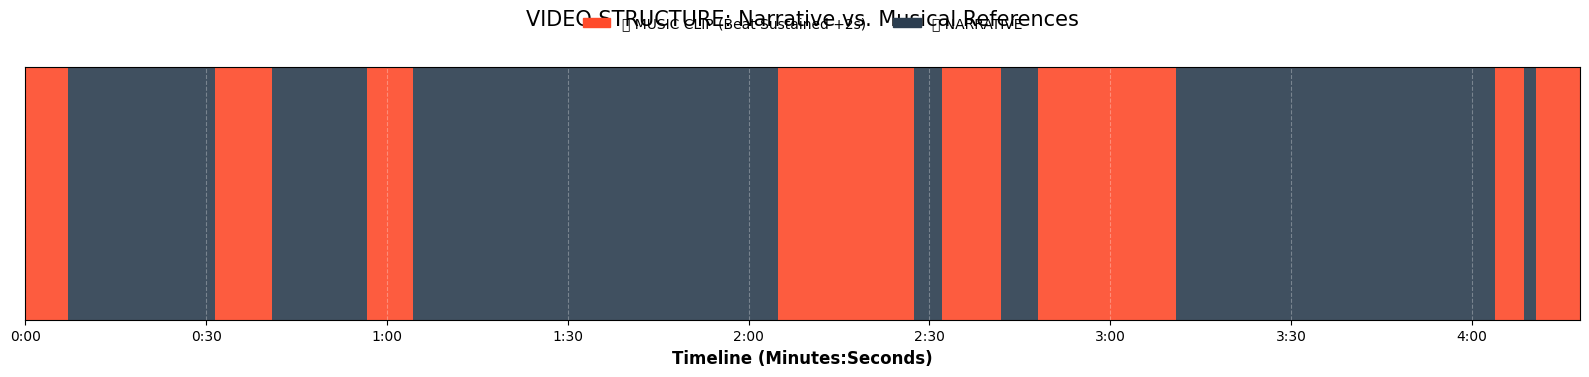

In [3]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# 1. Load the database
db_path = "../data/agent_db/godzilla_master_context.json"

def format_minutes_axis(x, pos):
    """Converts seconds to MM:SS format for the X-axis"""
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes}:{seconds:02d}"

print("📊 Generating visual timeline...")

try:
    with open(db_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Plot configuration
    fig, ax = plt.subplots(figsize=(16, 4))
    
    # Colors
    color_music = '#FF4B2B' # Vibrant Red for Music
    color_speech = '#2C3E50' # Dark Blue/Gray for Speech

    for segment in data:
        start = segment["start"]
        duration = segment["end"] - start
        current_color = color_music if segment["is_music_piece"] else color_speech
        
        # Draw the bar
        ax.broken_barh([(start, duration)], (0, 1), facecolors=current_color, alpha=0.9)

    # --- X-Axis Formatting (Minutes) ---
    ax.xaxis.set_major_formatter(FuncFormatter(format_minutes_axis))
    
    # Tick every 30 seconds for better resolution
    import numpy as np
    total_duration = data[-1]["end"]
    ax.set_xticks(np.arange(0, total_duration + 30, 30))

    ax.set_ylim(0, 1)
    ax.set_xlim(0, total_duration)
    ax.set_xlabel('Timeline (Minutes:Seconds)', fontsize=12, fontweight='bold')
    ax.set_yticks([]) 
    
    ax.set_title('VIDEO STRUCTURE: Narrative vs. Musical References', fontsize=15, pad=30)

    # Legend
    music_patch = mpatches.Patch(color=color_music, label='🎸 MUSIC CLIP (Beat Sustained +2s)')
    speech_patch = mpatches.Patch(color=color_speech, label='🗣️ NARRATIVE')
    plt.legend(handles=[music_patch, speech_patch], loc='upper center', 
               bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)

    ax.grid(axis='x', color='white', linestyle='--', alpha=0.3)
    ax.set_facecolor('#F4F4F4')

    plt.tight_layout()
    
    # Save image
    os.makedirs("../data/visuals", exist_ok=True)
    plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
    
    print("✅ Timeline generated successfully! Open: ../data/visuals/timeline_minutes.png")
    plt.show()

except Exception as e:
    print(f"❌ Visualization Error: {e}")